# Cab Fare Prediction: Complete Machine Learning Workshop
## Fare Estimation for Cab Rides - An EDA and Machine Learning Approach

**Author:**  Roshni Dodhi 
**Date:** October 2025  
**Project Type:** Supervised Learning - Regression  




<a id='section1'></a>
## 1. Introduction & Setup

### Project Overview
This project aims to build a machine learning model that predicts cab fares based on various ride features like distance, time, weather conditions, and surge pricing.

### Problem Type
- **Type:** Supervised Learning
- **Task:** Regression (predicting continuous numeric values)
- **Target Variable:** `price` (cab fare amount)



In [1]:
# ============================================
# CELL 1: Import Required Libraries
# ============================================

# Data manipulation and analysis
import pandas as pd              # For working with tabular data (like Excel sheets)
import numpy as np               # For numerical operations and array manipulations

# Data visualization libraries
import matplotlib.pyplot as plt  # For creating basic plots and charts
import seaborn as sns            # For advanced statistical visualizations
import plotly.express as px      # For interactive visualizations

# Machine learning libraries
from sklearn.model_selection import train_test_split  # For splitting data into train/test sets
from sklearn.preprocessing import StandardScaler, LabelEncoder  # For scaling and encoding data
from sklearn.linear_model import LinearRegression     # Linear regression model
from sklearn.tree import DecisionTreeRegressor        # Decision tree model
from sklearn.ensemble import RandomForestRegressor    # Random forest model

# Model evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Display settings for pandas dataframes
pd.set_option('display.max_columns', 200)  # Show more columns at once
pd.set_option('display.width', 120)        # Wider display

# Set random seed for reproducibility (ensures same results every time)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Enable inline plotting in Jupyter
%matplotlib inline

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(" All libraries imported successfully!")
print(f" Using random state: {RANDOM_STATE} for reproducibility")

 All libraries imported successfully!
 Using random state: 42 for reproducibility


<a id='section2'></a>
## 2. Data Loading & Initial Exploration

We'll load our dataset and perform initial exploration to understand:
- How many rows and columns we have
- What types of data are in each column
- Basic statistics about numeric columns
- If there are any missing values

In [2]:
# ============================================
# CELL 2: Load the Dataset
# ============================================

# Load the cab fare dataset from a CSV file

df = pd.read_csv("C:\\Users\\roshn\\OneDrive\\Desktop\\Build in Fellowship Project Updated\\Cab-Fare-Project\\cab-fare-analysis\\Original Dataset.csv")

# Display basic information
print(f"Dataset Shape (rows, columns): {df.shape}")
print(f"\nTotal Records: {len(df):,}")
print(f"Total Features: {df.shape[1]}")

# Show the first few rows
print("\n" + "="*80)
print("First 5 Rows of the Dataset:")
print("="*80)
df.head()

Dataset Shape (rows, columns): (693071, 57)

Total Records: 693,071
Total Features: 57

First 5 Rows of the Dataset:


,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,product_id,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,short_summary,long_summary,precipIntensity,precipProbability,humidity,windSpeed,windGust,windGustTime,visibility,temperatureHigh,temperatureHighTime,temperatureLow,temperatureLowTime,apparentTemperatureHigh,apparentTemperatureHighTime,apparentTemperatureLow,apparentTemperatureLowTime,icon,dewPoint,pressure,windBearing,cloudCover,uvIndex,visibility.1,ozone,sunriseTime,sunsetTime,moonPhase,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,lyft_line,Shared,5.0,0.44,1.0,42.2148,-71.033,42.34,37.12,Mostly Cloudy,Rain throughout the day.,0.0000,0.0,0.68,8.66,9.17,1545015600,10.000,43.68,1544968800,34.19,1545048000,37.95,1544968800,27.39,1545044400,partly-cloudy-night,32.70,1021.98,57,0.72,0,10.000,303.8,1544962084,1544994864,0.30,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,lyft_premier,Lux,11.0,0.44,1.0,42.2148,-71.033,43.58,37.35,Rain,"Rain until morning, starting again in the eve...",0.1299,1.0,0.94,11.98,11.98,1543291200,4.786,47.30,1543251600,42.10,1543298400,43.92,1543251600,36.20,1543291200,rain,41.83,1003.97,90,1.00,0,4.786,291.1,1543232969,1543266992,0.64,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,lyft,Lyft,7.0,0.44,1.0,42.2148,-71.033,38.33,32.93,Clear,Light rain in the morning.,0.0000,0.0,0.75,7.33,7.33,1543334400,10.000,47.55,1543320000,33.10,1543402800,44.12,1543320000,29.11,1543392000,clear-night,31.10,992.28,240,0.03,0,10.000,315.7,1543319437,1543353364,0.68,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,lyft_luxsuv,Lux Black XL,26.0,0.44,1.0,42.2148,-71.033,34.38,29.63,Clear,Partly cloudy throughout the day.,0.0000,0.0,0.73,5.28,5.28,1543514400,10.000,45.03,1543510800,28.90,1543579200,38.53,1543510800,26.20,1543575600,clear-night,26.64,1013.73,310,0.00,0,10.000,291.1,1543492370,1543526114,0.75,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,lyft_plus,Lyft XL,9.0,0.44,1.0,42.2148,-71.033,37.44,30.88,Partly Cloudy,Mostly cloudy throughout the day.,0.0000,0.0,0.70,9.14,9.14,1543446000,10.000,42.18,1543420800,36.71,1543478400,35.75,1543420800,30.29,1543460400,partly-cloudy-night,28.61,998.36,303,0.44,0,10.000,347.7,1543405904,1543439738,0.72,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [3]:
# ============================================
# CELL 3: Dataset Information
# ============================================

# Display column names, data types, and non-null counts
print("Dataset Information:")
print("="*80)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  object 
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  object 
 6   timezone                     693071 non-null  object 
 7   source                       693071 non-null  object 
 8   destination                  693071 non-null  object 
 9   cab_type                     693071 non-null  object 
 10  product_id                   693071 non-null  object 
 11  name                         693071 non-null  object 
 12  price                        637976 n

In [4]:
# ============================================
# CELL 4: Summary Statistics
# ============================================

# Get statistical summary of numeric columns
# This shows count, mean, std, min, 25%, 50% (median), 75%, max
print("Summary Statistics for Numeric Columns:")
print("="*80)
df.describe().T  # .T transposes the table for better readability

Summary Statistics for Numeric Columns:


,count,mean,std,min,25%,50%,75%,max
timestamp,693071.0,1.544046e+09,689192.492586,1.543204e+09,1.543444e+09,1.543737e+09,1.544828e+09,1.545161e+09
hour,693071.0,1.161914e+01,6.948114,0.000000e+00,6.000000e+00,1.200000e+01,1.800000e+01,2.300000e+01
day,693071.0,1.779436e+01,9.982286,1.000000e+00,1.300000e+01,1.700000e+01,2.800000e+01,3.000000e+01
month,693071.0,1.158668e+01,0.492429,1.100000e+01,1.100000e+01,1.200000e+01,1.200000e+01,1.200000e+01
price,637976.0,1.654513e+01,9.324359,2.500000e+00,9.000000e+00,1.350000e+01,2.250000e+01,9.750000e+01
distance,693071.0,2.189430e+00,1.138937,2.000000e-02,1.280000e+00,2.160000e+00,2.920000e+00,7.860000e+00
surge_multiplier,693071.0,1.013870e+00,0.091641,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
latitude,693071.0,4.233817e+01,0.047840,4.221480e+01,4.235030e+01,4.235190e+01,4.236470e+01,4.236610e+01
longitude,693071.0,-7.106615e+01,0.020302,-7.110540e+01,-7.108100e+01,-7.106310e+01,-7.105420e+01,-7.103300e+01
temperature,693071.0,3.958439e+01,6.726084,1.891000e+01,3.645000e+01,4.049000e+01,4.358000e+01,5.722000e+01


In [5]:
# ============================================
# CELL 5: Understanding Each Column
# ============================================

# Create a dictionary explaining what each column represents
column_descriptions = {
    'id': 'Unique identifier for each ride',
    'timestamp': 'Unix timestamp of when the ride was requested',
    'hour': 'Hour of the day (0-23)',
    'day': 'Day of the month',
    'month': 'Month of the year',
    'datetime': 'Formatted date and time of the ride',
    'timezone': 'Timezone where the ride occurred',
    'source': 'Pickup location',
    'destination': 'Drop-off location',
    'cab_type': 'Type of cab service (Uber or Lyft)',
    'product_id': 'Specific product/service type identifier',
    'name': 'Name of the ride type (e.g., UberX, Lyft, Shared)',
    'price': 'TARGET VARIABLE - Fare amount in dollars',
    'distance': 'Distance of the trip in miles',
    'surge_multiplier': 'Surge pricing multiplier (1.0 = no surge)',
    'latitude': 'Latitude coordinate of pickup location',
    'longitude': 'Longitude coordinate of pickup location',
    'temperature': 'Temperature at time of ride (Fahrenheit)',
    'apparentTemperature': 'Feels-like temperature',
    'short_summary': 'Brief weather condition',
    'long_summary': 'Detailed weather description',
    'precipIntensity': 'Precipitation intensity',
    'precipProbability': 'Probability of precipitation',
    'humidity': 'Humidity level (0-1)',
    'windSpeed': 'Wind speed in mph',
    'visibility': 'Visibility in miles',
    'icon': 'Weather icon/condition type'
}

# Create a DataFrame to display this information nicely
col_info = pd.DataFrame([
    {'Column': col, 'Description': desc, 'Data Type': str(df[col].dtype)}
    for col, desc in column_descriptions.items() if col in df.columns
])

print("Column Descriptions:")
print("="*80)
col_info

Column Descriptions:


,Column,Description,Data Type
0,id,Unique identifier for each ride,object
1,timestamp,Unix timestamp of when the ride was requested,float64
2,hour,Hour of the day (0-23),int64
3,day,Day of the month,int64
4,month,Month of the year,int64
5,datetime,Formatted date and time of the ride,object
6,timezone,Timezone where the ride occurred,object
7,source,Pickup location,object
8,destination,Drop-off location,object
9,cab_type,Type of cab service (Uber or Lyft),object


<a id='section3'></a>
## 3. Data Cleaning & Preprocessing


### Our Cleaning Steps:
1. Check for and handle missing values
2. Remove duplicate rows
3. Fix data types
4. Remove invalid/outlier values
5. Create useful features from existing data

In [6]:
# ============================================
# CELL 6: Check for Missing Values
# ============================================

# Count missing values in each column
missing_values = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Create a summary dataframe
missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Percentage': missing_percentage.values
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_summary) > 0:
    print("Columns with Missing Values:")
    print("="*80)
    print(missing_summary.to_string(index=False))
else:
    print(" No missing values found in the dataset!")

Columns with Missing Values:
Column  Missing Count  Percentage
 price          55095    7.949402


In [7]:
# ============================================
# CELL 7: Handle Missing Values
# ============================================

print("Handling Missing Values...")
print("="*80)

# Store original size
original_size = len(df)

# CRITICAL: Drop rows where the target variable (price) is missing
# We cannot predict without knowing the actual price!
if 'price' in df.columns:
    df = df.dropna(subset=['price'])
    print(f"Dropped {original_size - len(df)} rows with missing price values")

# For other important numeric columns, fill with median (middle value)
# Median is better than mean because it's not affected by extreme values
numeric_cols = ['distance', 'surge_multiplier', 'temperature', 'humidity', 'windSpeed']
for col in numeric_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f" Filled missing {col} with median: {median_value:.2f}")

# For categorical columns, fill with mode (most common value)
categorical_cols = ['cab_type', 'name', 'source', 'destination', 'short_summary']
for col in categorical_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f" Filled missing {col} with mode: {mode_value}")

print(f"\n Dataset size after handling missing values: {len(df):,} rows")

Handling Missing Values...
Dropped 55095 rows with missing price values

 Dataset size after handling missing values: 637,976 rows


In [8]:
# ============================================
# CELL 8: Remove Duplicate Rows
# ============================================

print("Checking for Duplicate Rows...")
print("="*80)

# Count duplicates
duplicate_count = df.duplicated().sum()
print(f"Found {duplicate_count} duplicate rows")

if duplicate_count > 0:
    # Remove duplicates, keeping the first occurrence
    before = len(df)
    df = df.drop_duplicates(keep='first')
    after = len(df)
    print(f" Removed {before - after} duplicate rows")
    print(f" Dataset now has {after:,} unique rows")
else:
    print(" No duplicate rows found!")

Checking for Duplicate Rows...
Found 0 duplicate rows
 No duplicate rows found!


In [9]:
# ============================================
# CELL 9: Fix Data Types
# ============================================

print("Fixing Data Types...")
print("="*80)

# Convert datetime column to proper datetime format if it exists
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    print("✓ Converted 'datetime' to datetime format")
    
    # Extract useful time-based features
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['day'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)  # 1 if weekend, 0 if weekday
    print(" Extracted time-based features: hour, day_of_week, is_weekend")

# Ensure numeric columns are actually numeric
numeric_columns = ['price', 'distance', 'surge_multiplier', 'temperature', 'humidity']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to number, set invalid to NaN

print("\n All data types fixed!")
print("\nCurrent Data Types:")
print(df.dtypes)

Fixing Data Types...
✓ Converted 'datetime' to datetime format
 Extracted time-based features: hour, day_of_week, is_weekend

 All data types fixed!

Current Data Types:
id                                     object
timestamp                             float64
hour                                    int32
day                                     int32
month                                   int32
datetime                       datetime64[ns]
timezone                               object
source                                 object
destination                            object
cab_type                               object
product_id                             object
name                                   object
price                                 float64
distance                              float64
surge_multiplier                      float64
latitude                              float64
longitude                             float64
temperature                           float64
ap

In [10]:
# ============================================
# CELL 10: Remove Invalid Values and Outliers
# ============================================

print("Removing Invalid Values and Outliers...")
print("="*80)

original_size = len(df)

# 1. Remove rows with negative or zero prices (doesn't make sense!)
if 'price' in df.columns:
    df = df[df['price'] > 0]
    print(f" Removed rows with invalid prices (≤ 0)")

# 2. Remove rows with negative or zero distance
if 'distance' in df.columns:
    df = df[df['distance'] > 0]
    print(f" Removed rows with invalid distance (≤ 0)")

# 3. Remove extreme price outliers using IQR method
# IQR = Interquartile Range (difference between 75th and 25th percentile)
if 'price' in df.columns:
    Q1 = df['price'].quantile(0.25)  # 25th percentile
    Q3 = df['price'].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1
    
    # Define outlier boundaries (values beyond 1.5*IQR from Q1/Q3)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
    print(f" Removed price outliers (kept values between ${lower_bound:.2f} and ${upper_bound:.2f})")

# 4. Remove extreme distance outliers
if 'distance' in df.columns:
    # Remove trips longer than 100 miles (likely data errors)
    df = df[df['distance'] <= 100]
    print(f" Removed trips with distance > 100 miles")

# 5. Ensure surge multiplier is reasonable (between 1.0 and 5.0)
if 'surge_multiplier' in df.columns:
    df = df[(df['surge_multiplier'] >= 1.0) & (df['surge_multiplier'] <= 5.0)]
    print(f" Removed invalid surge multiplier values (kept 1.0 to 5.0)")

rows_removed = original_size - len(df)
percent_removed = (rows_removed / original_size) * 100

print(f"\n Removed {rows_removed:,} total rows ({percent_removed:.2f}%)")
print(f" Final clean dataset: {len(df):,} rows")

Removing Invalid Values and Outliers...
 Removed rows with invalid prices (≤ 0)
 Removed rows with invalid distance (≤ 0)
 Removed price outliers (kept values between $-11.25 and $42.75)
 Removed trips with distance > 100 miles
 Removed invalid surge multiplier values (kept 1.0 to 5.0)

 Removed 5,589 total rows (0.88%)
 Final clean dataset: 632,387 rows


In [11]:
# ============================================
# CELL 11: Save Cleaned Dataset
# ============================================

# Save the cleaned dataset for future use
df.to_csv('cab_rides_cleaned.csv', index=False)
print(" Cleaned dataset saved as 'cab_rides_cleaned.csv'")
print(f"\nFinal Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

 Cleaned dataset saved as 'cab_rides_cleaned.csv'

Final Dataset Shape: (632387, 59)
Rows: 632,387 | Columns: 59


<a id='section4'></a>
## 4. Exploratory Data Analysis (EDA)



### Our EDA Plan:
1. Analyze target variable (price) distribution
2. Explore relationships with numeric features
3. Analyze categorical features
4. Time-based analysis
5. Weather impact analysis
6. Correlation analysis

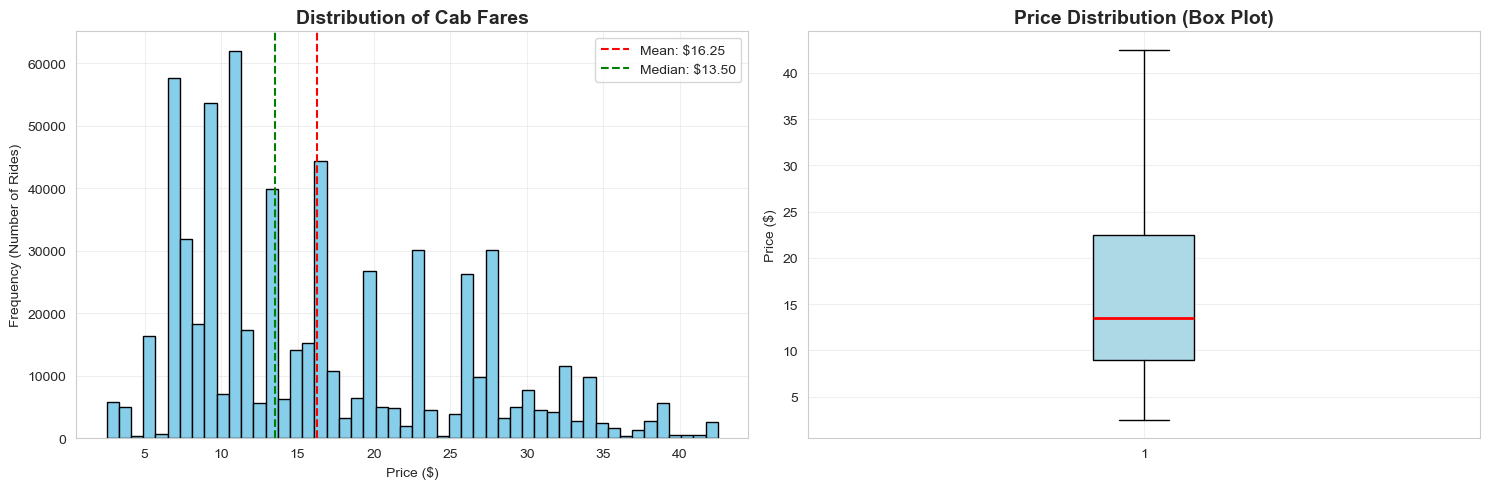

Price Statistics:
Mean Price: $16.25
Median Price: $13.50
Standard Deviation: $8.77
Min Price: $2.50
Max Price: $42.50

 Insight: Most rides are concentrated in the lower price range, with a long tail of higher-priced rides.


In [12]:
# ============================================
# CELL 12: Analyze Price Distribution
# ============================================

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram showing frequency of different price ranges
axes[0].hist(df['price'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Cab Fares', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency (Number of Rides)')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["price"].mean():.2f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f'Median: ${df["price"].median():.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot showing price distribution with quartiles
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Price Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Price Statistics:")
print("="*80)
print(f"Mean Price: ${df['price'].mean():.2f}")
print(f"Median Price: ${df['price'].median():.2f}")
print(f"Standard Deviation: ${df['price'].std():.2f}")
print(f"Min Price: ${df['price'].min():.2f}")
print(f"Max Price: ${df['price'].max():.2f}")
print("\n Insight: Most rides are concentrated in the lower price range, with a long tail of higher-priced rides.")

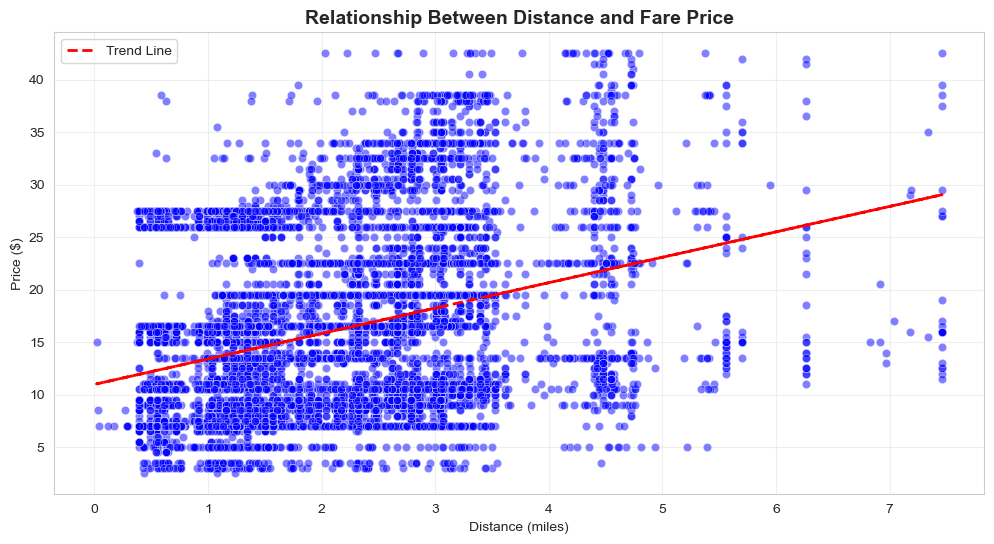


Correlation between Distance and Price: 0.319

 Insight: There's a strong positive relationship - as distance increases, price increases.


In [13]:
# ============================================
# CELL 13: Distance vs Price Analysis
# ============================================

# Create scatter plot with trend line
plt.figure(figsize=(12, 6))

# Sample data if dataset is too large (for better visualization)
if len(df) > 10000:
    sample_df = df.sample(10000, random_state=RANDOM_STATE)
else:
    sample_df = df

# Create scatter plot
sns.scatterplot(data=sample_df, x='distance', y='price', alpha=0.5, color='blue')

# Add trend line
z = np.polyfit(sample_df['distance'], sample_df['price'], 1)  # Linear fit
p = np.poly1d(z)
plt.plot(sample_df['distance'], p(sample_df['distance']), "r--", linewidth=2, label='Trend Line')

plt.title('Relationship Between Distance and Fare Price', fontsize=14, fontweight='bold')
plt.xlabel('Distance (miles)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation
correlation = df['distance'].corr(df['price'])
print(f"\nCorrelation between Distance and Price: {correlation:.3f}")
print("\n Insight: There's a strong positive relationship - as distance increases, price increases.")

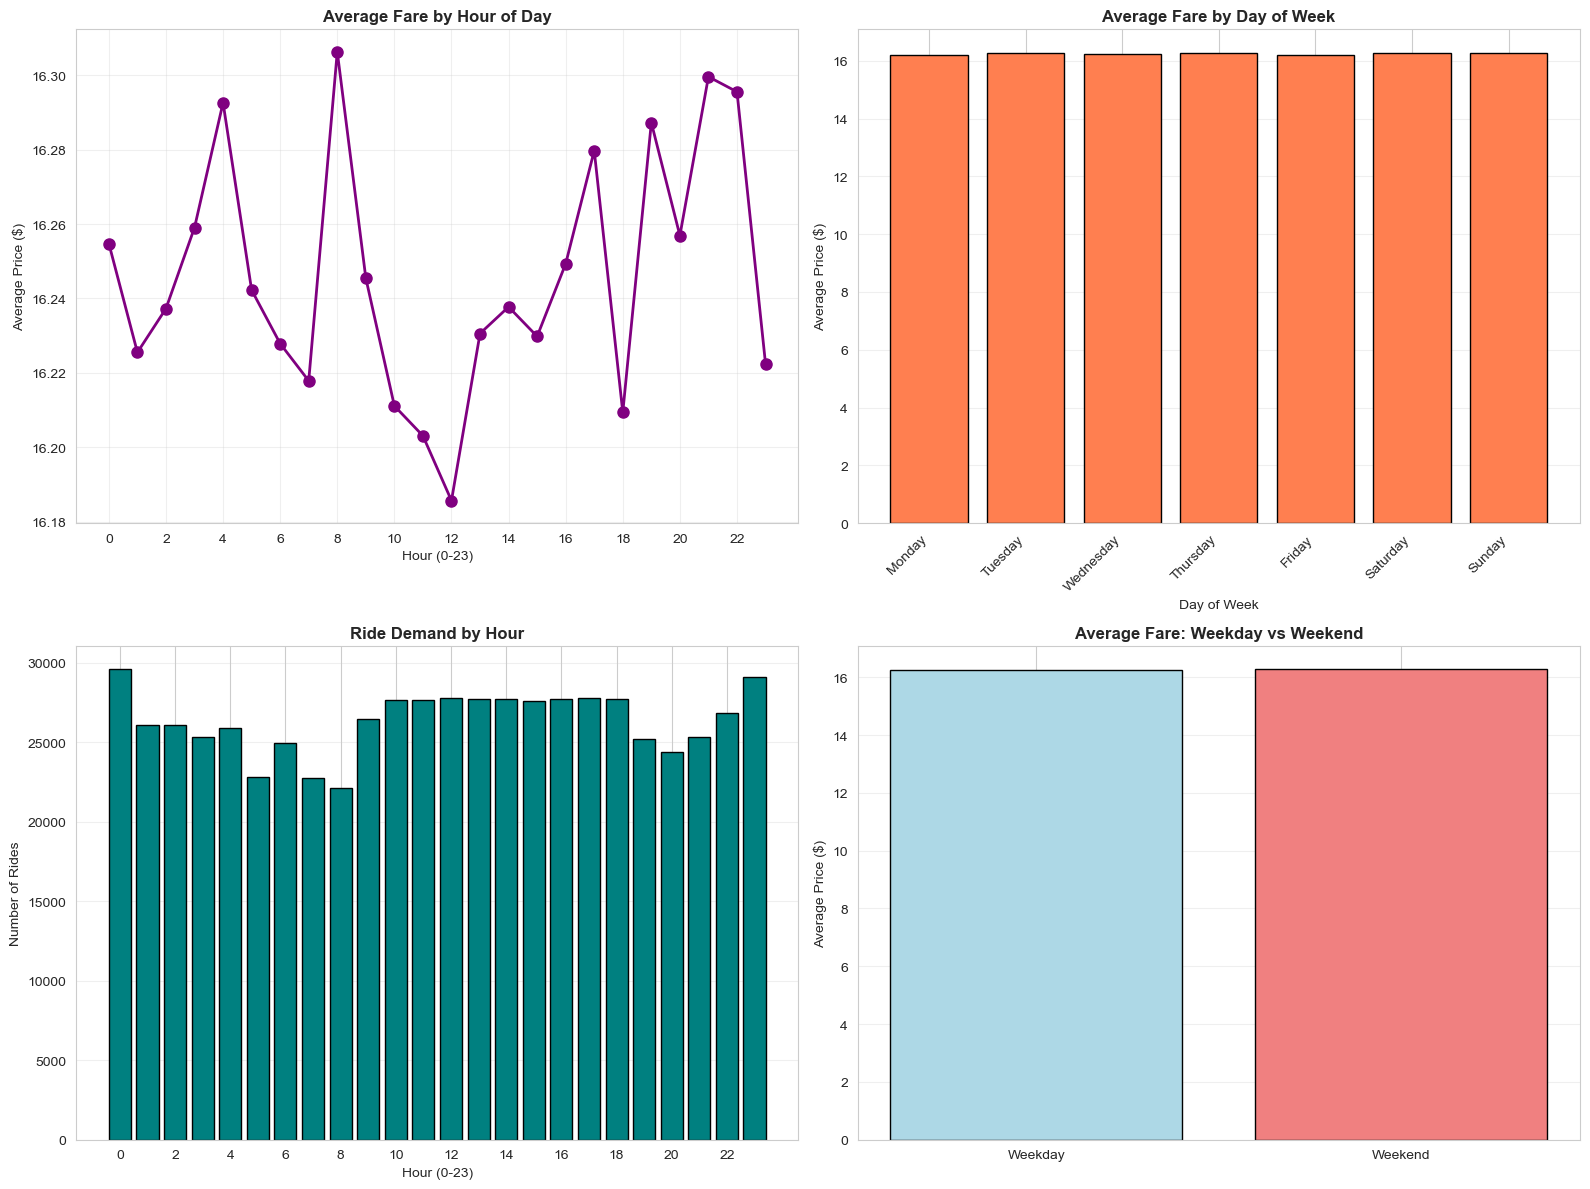


 Key Insights:
- Peak hours likely show higher demand and potentially higher prices
- Weekend patterns may differ from weekdays
- Late night/early morning hours might have different pricing dynamics


In [14]:
# ============================================
# CELL 14: Time-Based Analysis
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average price by hour of day
hourly_avg = df.groupby('hour')['price'].mean().reset_index()
axes[0, 0].plot(hourly_avg['hour'], hourly_avg['price'], marker='o', linewidth=2, markersize=8, color='purple')
axes[0, 0].set_title('Average Fare by Hour of Day', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour (0-23)')
axes[0, 0].set_ylabel('Average Price ($)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# 2. Average price by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('day_of_week')['price'].mean().reset_index()
axes[0, 1].bar(daily_avg['day_of_week'], daily_avg['price'], color='coral', edgecolor='black')
axes[0, 1].set_title('Average Fare by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Price ($)')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Ride count by hour (demand pattern)
hourly_count = df.groupby('hour').size().reset_index(name='count')
axes[1, 0].bar(hourly_count['hour'], hourly_count['count'], color='teal', edgecolor='black')
axes[1, 0].set_title('Ride Demand by Hour', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hour (0-23)')
axes[1, 0].set_ylabel('Number of Rides')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_xticks(range(0, 24, 2))

# 4. Weekend vs Weekday prices
if 'is_weekend' in df.columns:
    weekend_comparison = df.groupby('is_weekend')['price'].mean()
    axes[1, 1].bar(['Weekday', 'Weekend'], weekend_comparison.values, color=['lightblue', 'lightcoral'], edgecolor='black')
    axes[1, 1].set_title('Average Fare: Weekday vs Weekend', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Average Price ($)')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Key Insights:")
print("- Peak hours likely show higher demand and potentially higher prices")
print("- Weekend patterns may differ from weekdays")
print("- Late night/early morning hours might have different pricing dynamics")

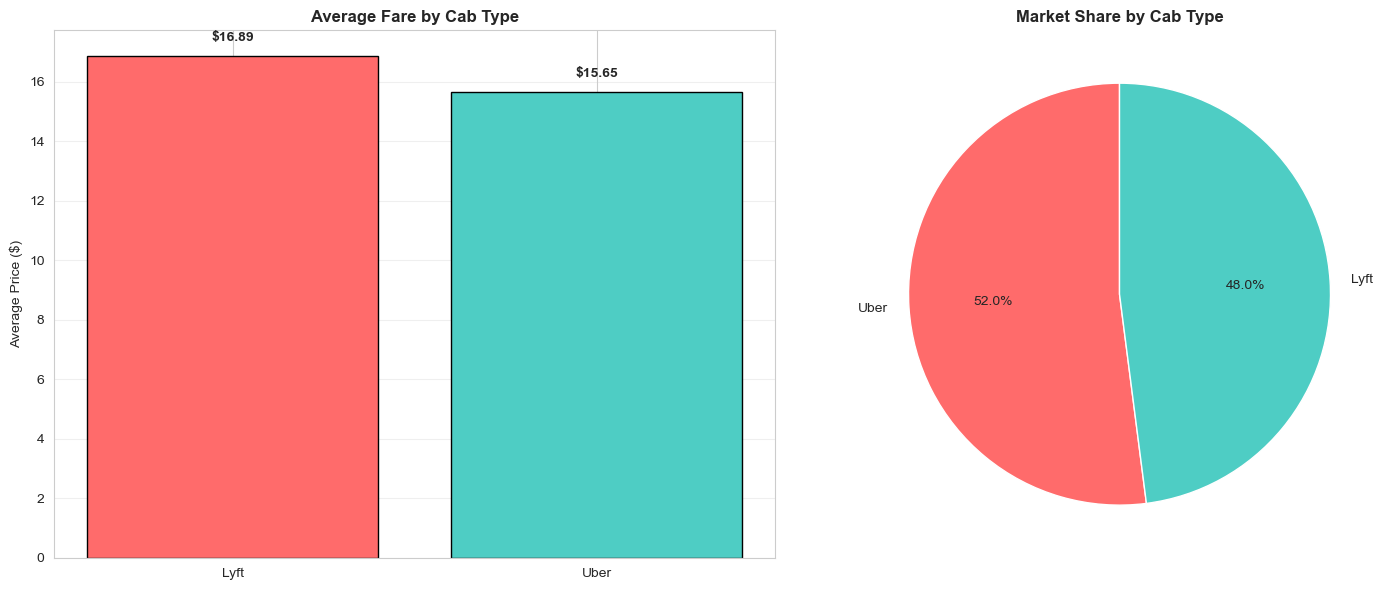


 Insight: Compare pricing strategies and market share between different cab services.


In [15]:
# ============================================
# CELL 15: Cab Type Analysis
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Average price by cab type
if 'cab_type' in df.columns:
    cab_avg = df.groupby('cab_type')['price'].mean().sort_values(ascending=False)
    axes[0].bar(cab_avg.index, cab_avg.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
    axes[0].set_title('Average Fare by Cab Type', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Average Price ($)')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(cab_avg.values):
        axes[0].text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')

# 2. Ride count by cab type (market share)
if 'cab_type' in df.columns:
    cab_counts = df['cab_type'].value_counts()
    axes[1].pie(cab_counts.values, labels=cab_counts.index, autopct='%1.1f%%',
                colors=['#FF6B6B', '#4ECDC4'], startangle=90)
    axes[1].set_title('Market Share by Cab Type', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Insight: Compare pricing strategies and market share between different cab services.")

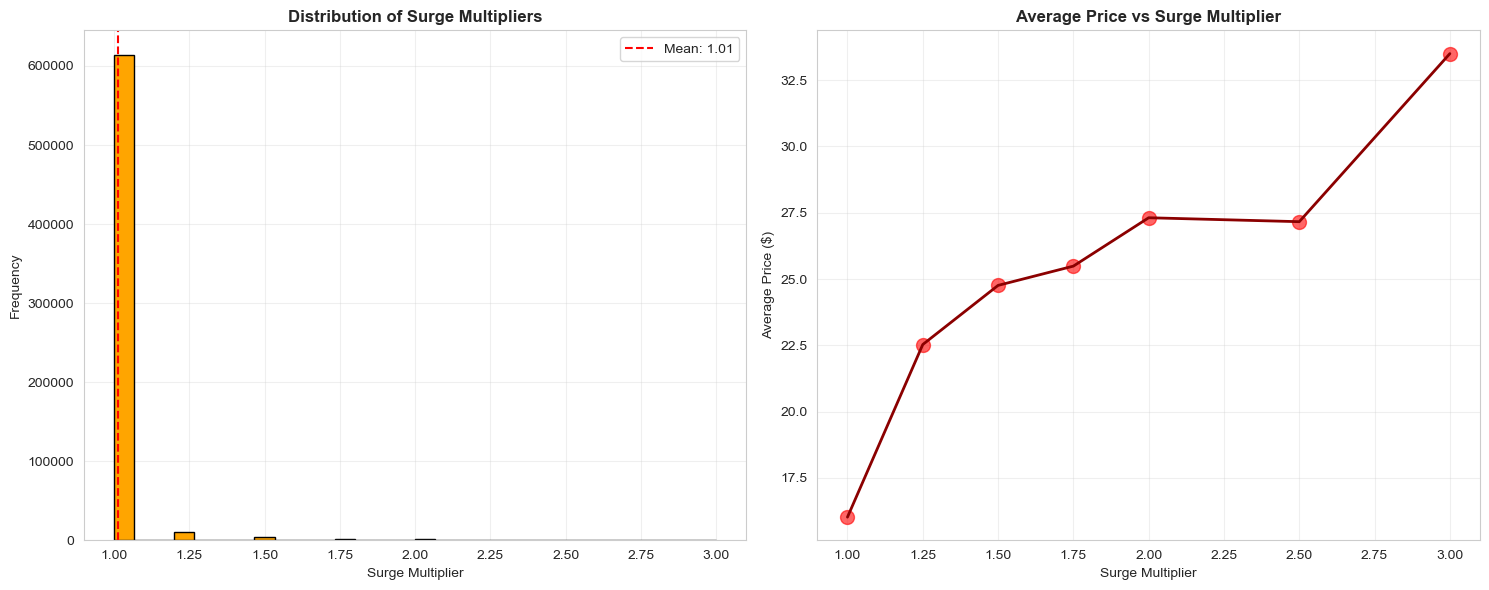


Surge Pricing Statistics:
Rides with surge pricing: 18,163 (2.9%)
Average surge multiplier: 1.01
Max surge multiplier: 3.00

 Insight: Surge pricing significantly impacts fare prices during high-demand periods.


In [16]:
# ============================================
# CELL 16: Surge Pricing Analysis
# ============================================

if 'surge_multiplier' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Distribution of surge multipliers
    axes[0].hist(df['surge_multiplier'], bins=30, color='orange', edgecolor='black')
    axes[0].set_title('Distribution of Surge Multipliers', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Surge Multiplier')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(df['surge_multiplier'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df["surge_multiplier"].mean():.2f}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Price vs Surge Multiplier
    surge_price = df.groupby('surge_multiplier')['price'].mean().reset_index()
    axes[1].scatter(surge_price['surge_multiplier'], surge_price['price'], s=100, color='red', alpha=0.6)
    axes[1].plot(surge_price['surge_multiplier'], surge_price['price'], color='darkred', linewidth=2)
    axes[1].set_title('Average Price vs Surge Multiplier', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Surge Multiplier')
    axes[1].set_ylabel('Average Price ($)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate percentage of rides with surge pricing
    surge_rides = (df['surge_multiplier'] > 1.0).sum()
    surge_percentage = (surge_rides / len(df)) * 100
    
    print(f"\nSurge Pricing Statistics:")
    print("="*80)
    print(f"Rides with surge pricing: {surge_rides:,} ({surge_percentage:.1f}%)")
    print(f"Average surge multiplier: {df['surge_multiplier'].mean():.2f}")
    print(f"Max surge multiplier: {df['surge_multiplier'].max():.2f}")
    print("\n Insight: Surge pricing significantly impacts fare prices during high-demand periods.")

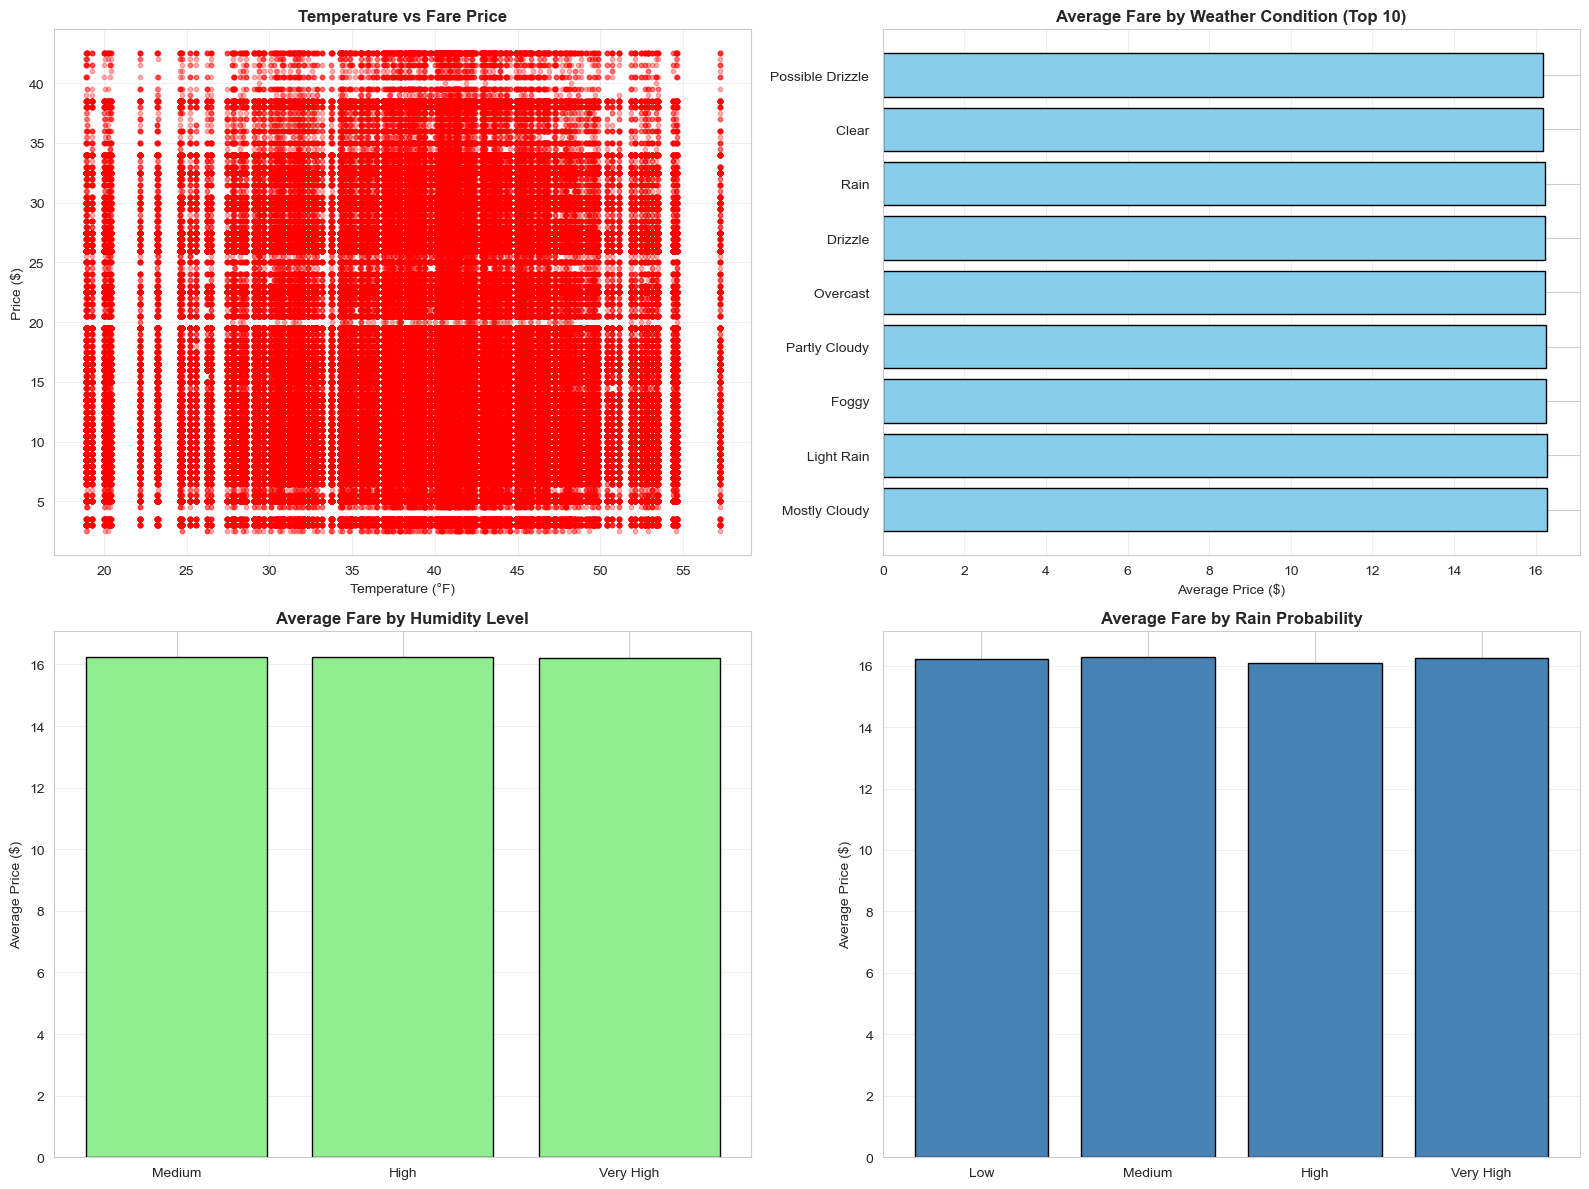


 Insight: Bad weather conditions (rain, storms) often lead to higher demand and prices.


In [17]:
# ============================================
# CELL 17: Weather Impact Analysis
# ============================================

if 'temperature' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Temperature vs Price
    axes[0, 0].scatter(df['temperature'], df['price'], alpha=0.3, s=10, color='red')
    axes[0, 0].set_title('Temperature vs Fare Price', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Temperature (°F)')
    axes[0, 0].set_ylabel('Price ($)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Weather condition impact
    if 'short_summary' in df.columns:
        weather_avg = df.groupby('short_summary')['price'].mean().sort_values(ascending=False).head(10)
        axes[0, 1].barh(weather_avg.index, weather_avg.values, color='skyblue', edgecolor='black')
        axes[0, 1].set_title('Average Fare by Weather Condition (Top 10)', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Average Price ($)')
        axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # 3. Humidity impact
    if 'humidity' in df.columns:
        # Create humidity bins
        df['humidity_bin'] = pd.cut(df['humidity'], bins=[0, 0.3, 0.6, 0.9, 1.0], 
                                     labels=['Low', 'Medium', 'High', 'Very High'])
        humidity_avg = df.groupby('humidity_bin')['price'].mean()
        axes[1, 0].bar(humidity_avg.index, humidity_avg.values, color='lightgreen', edgecolor='black')
        axes[1, 0].set_title('Average Fare by Humidity Level', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Average Price ($)')
        axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. Precipitation probability impact
    if 'precipProbability' in df.columns:
        df['rain_category'] = pd.cut(df['precipProbability'], bins=[0, 0.25, 0.5, 0.75, 1.0],
                                      labels=['Low', 'Medium', 'High', 'Very High'])
        rain_avg = df.groupby('rain_category')['price'].mean()
        axes[1, 1].bar(rain_avg.index, rain_avg.values, color='steelblue', edgecolor='black')
        axes[1, 1].set_title('Average Fare by Rain Probability', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Average Price ($)')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n Insight: Bad weather conditions (rain, storms) often lead to higher demand and prices.")

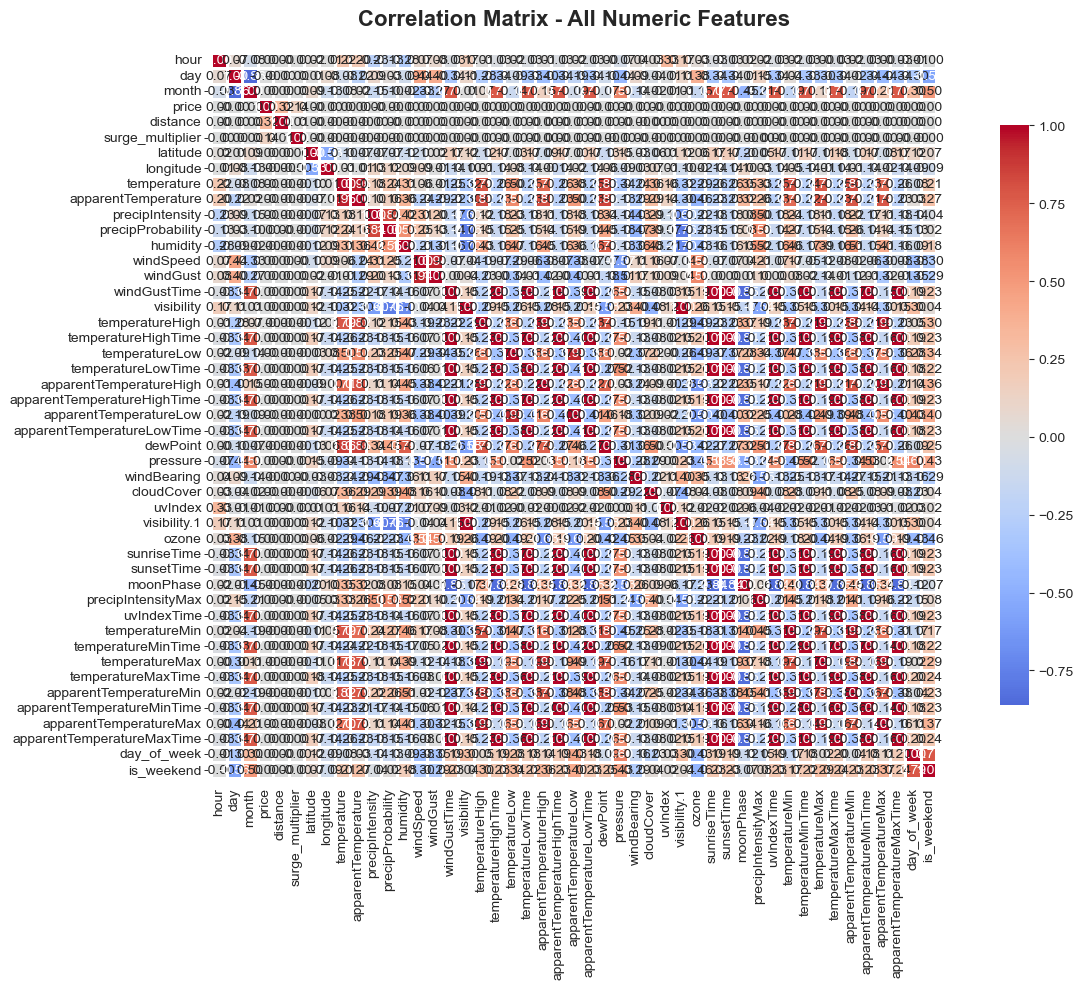


Features Most Correlated with Price:
price                         1.000000
distance                      0.318671
surge_multiplier              0.141238
month                         0.001648
is_weekend                    0.001639
latitude                      0.001559
windGustTime                  0.001555
apparentTemperatureMinTime    0.001509
temperatureMinTime            0.001465
temperatureMaxTime            0.001451

 Key Insights:
- Positive correlation (closer to +1): Feature increases with price
- Negative correlation (closer to -1): Feature decreases as price increases
- Correlation near 0: Little to no linear relationship


In [18]:
# ============================================
# CELL 18: Correlation Analysis
# ============================================

# Select numeric columns for correlation analysis
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns and other non-predictive columns
cols_to_remove = ['id', 'timestamp']
numeric_features = [col for col in numeric_features if col not in cols_to_remove]

# Calculate correlation matrix
correlation_matrix = df[numeric_features].corr()

# Create a large heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show features most correlated with price
if 'price' in correlation_matrix.columns:
    price_correlations = correlation_matrix['price'].sort_values(ascending=False)
    print("\nFeatures Most Correlated with Price:")
    print("="*80)
    print(price_correlations.head(10).to_string())
    
    print("\n Key Insights:")
    print("- Positive correlation (closer to +1): Feature increases with price")
    print("- Negative correlation (closer to -1): Feature decreases as price increases")
    print("- Correlation near 0: Little to no linear relationship")

<a id='section5'></a>
## 5. Feature Engineering


### Steps:
1. **Feature Creation** - Make new useful features
2. **Feature Encoding** - Convert categories to numbers
3. **Feature Scaling** - Get all numbers on similar scale
4. **Feature Selection** - Keep only the most important features

In [19]:
# ============================================
# CELL 19: Create New Features
# ============================================

print("Creating New Features...")
print("="*80)

# 1. Time-based features (if not already created)
if 'is_rush_hour' not in df.columns and 'hour' in df.columns:
    # Rush hours: 7-9 AM and 5-7 PM
    df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
    print(" Created 'is_rush_hour' (1 if rush hour, 0 otherwise)")

if 'time_of_day' not in df.columns and 'hour' in df.columns:
    # Categorize time of day
    def get_time_of_day(hour):
        if 5 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 17:
            return 'Afternoon'
        elif 17 <= hour < 21:
            return 'Evening'
        else:
            return 'Night'
    
    df['time_of_day'] = df['hour'].apply(get_time_of_day)
    print(" Created 'time_of_day' (Morning/Afternoon/Evening/Night)")

# 2. Distance-based features
if 'distance' in df.columns and 'distance_category' not in df.columns:
    # Categorize trips by distance
    df['distance_category'] = pd.cut(df['distance'], 
                                      bins=[0, 2, 5, 10, 100],
                                      labels=['Short', 'Medium', 'Long', 'Very Long'])
    print(" Created 'distance_category' (Short/Medium/Long/Very Long)")

# 3. Price per mile (efficiency metric)
if 'price' in df.columns and 'distance' in df.columns and 'price_per_mile' not in df.columns:
    df['price_per_mile'] = df['price'] / df['distance'].replace(0, 0.1)  # Avoid division by zero
    print(" Created 'price_per_mile'")

# 4. Is surge active (binary)
if 'surge_multiplier' in df.columns and 'has_surge' not in df.columns:
    df['has_surge'] = (df['surge_multiplier'] > 1.0).astype(int)
    print(" Created 'has_surge' (1 if surge active, 0 otherwise)")

# 5. Weather severity (if weather columns exist)
if all(col in df.columns for col in ['precipProbability', 'windSpeed', 'humidity']):
    # Create a composite weather severity score
    df['weather_severity'] = (
        df['precipProbability'] * 0.4 +  # Rain probability (40% weight)
        (df['windSpeed'] / df['windSpeed'].max()) * 0.3 +  # Normalized wind (30% weight)
        df['humidity'] * 0.3  # Humidity (30% weight)
    )
    print(" Created 'weather_severity' (composite weather badness score)")

# 6. Route popularity (frequency of source-destination pair)
if 'source' in df.columns and 'destination' in df.columns:
    df['route'] = df['source'] + ' → ' + df['destination']
    route_counts = df['route'].value_counts()
    df['route_popularity'] = df['route'].map(route_counts)
    print(" Created 'route_popularity' (how often this route is taken)")

print(f"\n Total features now: {df.shape[1]}")
print("\n These new features capture patterns that might help predict prices better!")

Creating New Features...
 Created 'is_rush_hour' (1 if rush hour, 0 otherwise)
 Created 'time_of_day' (Morning/Afternoon/Evening/Night)
 Created 'distance_category' (Short/Medium/Long/Very Long)
 Created 'price_per_mile'
 Created 'has_surge' (1 if surge active, 0 otherwise)
 Created 'weather_severity' (composite weather badness score)
 Created 'route_popularity' (how often this route is taken)

 Total features now: 69

 These new features capture patterns that might help predict prices better!


In [20]:
# ============================================
# CELL 20: Encode Categorical Variables
# ============================================

print("Encoding Categorical Variables...")
print("="*80)
print("Why? Machine learning models only understand numbers, not text!\n")

# Create a copy to preserve original data
df_encoded = df.copy()

# 1. Label Encoding for binary/ordinal variables
# (When categories have an order or are just 2 values)
label_encode_cols = ['cab_type', 'has_surge', 'is_rush_hour', 'is_weekend']
le = LabelEncoder()

for col in label_encode_cols:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        print(f" Label encoded '{col}'")

# 2. One-Hot Encoding for nominal variables
# (When categories have NO order, like ride type, weather, location)
onehot_cols = ['name', 'short_summary', 'time_of_day', 'distance_category']
onehot_cols = [col for col in onehot_cols if col in df_encoded.columns]

if len(onehot_cols) > 0:
    print(f"\nOne-hot encoding: {', '.join(onehot_cols)}")
    df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, drop_first=True, dtype=int)
    print(f" Created {len(df_encoded.columns) - len(df.columns)} new binary columns")

# 3. For location columns, use frequency encoding (map to how often they appear)
location_cols = ['source', 'destination']
for col in location_cols:
    if col in df_encoded.columns:
        freq_map = df_encoded[col].value_counts(normalize=True).to_dict()
        df_encoded[f'{col}_freq'] = df_encoded[col].map(freq_map)
        df_encoded.drop(columns=[col], inplace=True)  # Drop original column
        print(f" Frequency encoded '{col}'")

print(f"\n Final encoded dataset shape: {df_encoded.shape}")
print(f"  - Rows: {df_encoded.shape[0]:,}")
print(f"  - Features: {df_encoded.shape[1]}")

Encoding Categorical Variables...
Why? Machine learning models only understand numbers, not text!

 Label encoded 'cab_type'
 Label encoded 'has_surge'
 Label encoded 'is_rush_hour'
 Label encoded 'is_weekend'

One-hot encoding: name, short_summary, time_of_day, distance_category
 Created 21 new binary columns
 Frequency encoded 'source'
 Frequency encoded 'destination'

 Final encoded dataset shape: (632387, 90)
  - Rows: 632,387
  - Features: 90


In [21]:
# ============================================
# CELL 21: Feature Selection (FIXED)
# ============================================

print("Selecting Most Important Features...")
print("="*80)

# First, let's see what columns we have
print("\nCurrent columns in df_encoded:")
print(df_encoded.columns.tolist())

# Separate the target variable first
if 'price' in df_encoded.columns:
    y = df_encoded['price']
    df_features = df_encoded.drop('price', axis=1)
else:
    print(" 'price' column not found!")
    df_features = df_encoded.copy()

# Drop non-predictive columns
columns_to_drop = [
    'id', 'timestamp', 'datetime', 'timezone', 'product_id',
    'route', 'humidity_bin', 'rain_category',
    'latitude', 'longitude',
    'long_summary',  # Add this - detailed weather text
    'icon'  # Add this - weather icon
]

# Drop columns that exist
columns_to_drop = [col for col in columns_to_drop if col in df_features.columns]
df_features.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print(f"\n Dropped {len(columns_to_drop)} non-predictive columns")

# NOW THE KEY FIX: Select only numeric columns
print("\nSelecting only numeric columns...")
numeric_columns = df_features.select_dtypes(include=[np.number]).columns.tolist()
df_features = df_features[numeric_columns]

print(f" Kept {len(numeric_columns)} numeric features")

# Check for any remaining non-numeric columns
non_numeric = df_features.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric) > 0:
    print(f"\n  Still have {len(non_numeric)} non-numeric columns:")
    print(non_numeric)
    print("Dropping them...")
    df_features = df_features.select_dtypes(include=[np.number])

# Handle any remaining missing values
df_features = df_features.fillna(df_features.median())

# Now assign to X
X = df_features

print(f"\n Prepared data for modeling:")
print(f"  - Features (X): {X.shape}")
print(f"  - Target (y): {y.shape}")
print(f"\n Final feature list ({len(X.columns)} features):")
print(X.columns.tolist())

# Verify all columns are numeric
print("\n Data type check:")
print(X.dtypes.value_counts())

Selecting Most Important Features...

Current columns in df_encoded:
['id', 'timestamp', 'hour', 'day', 'month', 'datetime', 'timezone', 'cab_type', 'product_id', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'long_summary', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'windGustTime', 'visibility', 'temperatureHigh', 'temperatureHighTime', 'temperatureLow', 'temperatureLowTime', 'apparentTemperatureHigh', 'apparentTemperatureHighTime', 'apparentTemperatureLow', 'apparentTemperatureLowTime', 'icon', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'moonPhase', 'precipIntensityMax', 'uvIndexTime', 'temperatureMin', 'temperatureMinTime', 'temperatureMax', 'temperatureMaxTime', 'apparentTemperatureMin', 'apparentTemperatureMinTime', 'apparentTemperatureMax', 'apparentTemperatureMaxTime', 'day_of_week', 'is_weekend', 'humidity_bin', '

In [22]:
# ============================================
# CELL 22: Feature Scaling
# ============================================

print("Scaling Features...")
print("="*80)
print("Why scale? Different features have different ranges.")
print("Example: Distance (0-100 miles) vs Surge (1-3). We need to normalize them!\n")

# Initialize the scaler
# StandardScaler: transforms features to have mean=0 and std=1
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(" All features scaled using StandardScaler")
print(f"\nBefore scaling - Distance range: {X['distance'].min():.2f} to {X['distance'].max():.2f}")
print(f"After scaling - Distance range: {X_scaled['distance'].min():.2f} to {X_scaled['distance'].max():.2f}")
print("\n Now all features are on a similar scale, which helps models train better!")

Scaling Features...
Why scale? Different features have different ranges.
Example: Distance (0-100 miles) vs Surge (1-3). We need to normalize them!

 All features scaled using StandardScaler

Before scaling - Distance range: 0.02 to 7.86
After scaling - Distance range: -1.93 to 5.09

 Now all features are on a similar scale, which helps models train better!


<a id='section6'></a>
## 6. Model Building

### Train-Test Split
We split our data into three parts:
1. **Training Set (70%)** - Used to train the model
2. **Validation Set (15%)** - Used to tune the model
3. **Test Set (15%)** - Used to evaluate final performance


### Models We'll Build:
1. **Linear Regression** - Simple, interpretable baseline
2. **Decision Tree** - Captures non-linear patterns
3. **Random Forest** - Ensemble of trees for better accuracy


In [23]:
# ============================================
# CELL 23: Train-Test-Validation Split
# ============================================

print("Splitting Data into Train/Validation/Test Sets...")
print("="*80)

# First split: 85% train+val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.15, 
    random_state=RANDOM_STATE
)

# Second split: 70% train, 15% validation (from the 85%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 of total
    random_state=RANDOM_STATE
)

print(f"Training Set:   {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation Set: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test Set:       {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTotal:          {len(X):,} samples")

print("\n The model will learn from training data, tune on validation, and be evaluated on test data.")

Splitting Data into Train/Validation/Test Sets...
Training Set:   442,923 samples (70.0%)
Validation Set: 94,605 samples (15.0%)
Test Set:       94,859 samples (15.0%)

Total:          632,387 samples

 The model will learn from training data, tune on validation, and be evaluated on test data.


In [24]:
# ============================================
# CELL 24: Model 1 - Linear Regression
# ============================================

print("Training Model 1: Linear Regression")
print("="*80)
print("How it works: Finds the best straight line (or flat plane) through the data.")
print("Formula: Price = b₀ + b₁(Distance) + b₂(Surge) + ... + bₙ(Feature_n)\n")

# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
lr_train_pred = lr_model.predict(X_train)
lr_val_pred = lr_model.predict(X_val)
lr_test_pred = lr_model.predict(X_test)

print(" Linear Regression trained successfully!")
print(f"\nModel parameters: {lr_model.coef_.shape[0]} coefficients learned")

# Show top 5 most important features
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 5 Most Important Features:")
print(feature_importance.head().to_string(index=False))

Training Model 1: Linear Regression
How it works: Finds the best straight line (or flat plane) through the data.
Formula: Price = b₀ + b₁(Distance) + b₂(Surge) + ... + bₙ(Feature_n)

 Linear Regression trained successfully!

Model parameters: 77 coefficients learned

Top 5 Most Important Features:
          Feature  Coefficient
       sunsetTime    81.778941
      sunriseTime   -65.952183
      uvIndexTime   -12.668740
name_Lux Black XL     3.422457
    name_UberPool    -3.291629


In [25]:
# ============================================
# CELL 25: Model 2 - Decision Tree
# ============================================

print("Training Model 2: Decision Tree Regressor")
print("="*80)
print("How it works: Makes a series of yes/no decisions based on features.")
print("Example: Is distance > 5 miles? → Yes → Is surge active? → Yes → Predict $25\n")

# Initialize the model with some constraints to prevent overfitting
dt_model = DecisionTreeRegressor(
    max_depth=10,           # Maximum tree depth
    min_samples_split=100,  # Minimum samples to split a node
    min_samples_leaf=50,    # Minimum samples in a leaf
    random_state=RANDOM_STATE
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_train_pred = dt_model.predict(X_train)
dt_val_pred = dt_model.predict(X_val)
dt_test_pred = dt_model.predict(X_test)

print(" Decision Tree trained successfully!")
print(f"\nTree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

# Show feature importance
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Most Important Features:")
print(dt_importance.head().to_string(index=False))

Training Model 2: Decision Tree Regressor
How it works: Makes a series of yes/no decisions based on features.
Example: Is distance > 5 miles? → Yes → Is surge active? → Yes → Predict $25

 Decision Tree trained successfully!

Tree depth: 10
Number of leaves: 778

Top 5 Most Important Features:
       Feature  Importance
price_per_mile    0.546364
      distance    0.430676
   name_Shared    0.011180
name_Lux Black    0.006919
     has_surge    0.001973


Training Model 3: Random Forest Regressor
How it works: Builds many decision trees and averages their predictions.
Like asking 100 experts and taking the average of their answers!

Training... (this may take a minute)
 Random Forest trained successfully!

Number of trees: 100

Top 10 Most Important Features:
                 Feature  Importance
          price_per_mile    0.262369
       name_Lux Black XL    0.152021
          name_Black SUV    0.134431
                distance    0.095549
             name_Shared    0.063069
distance_category_Medium    0.049701
           name_UberPool    0.038706
               name_Lyft    0.028703
                name_WAV    0.027920
              name_UberX    0.027466


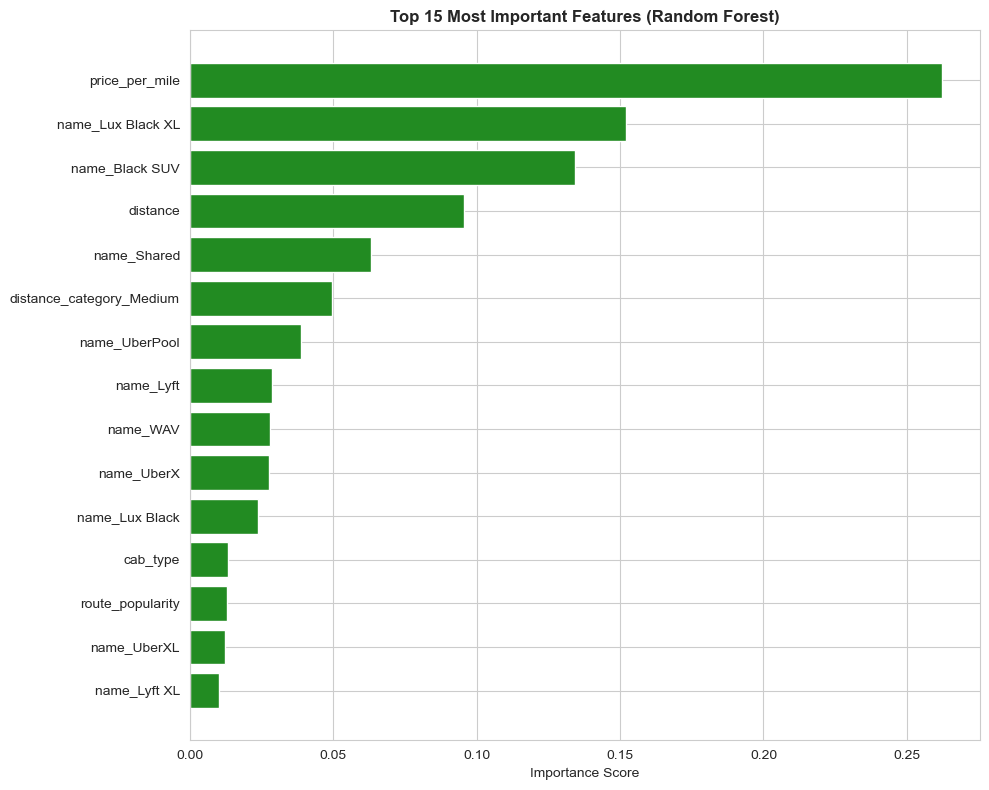

In [26]:
# ============================================
# CELL 26: Model 3 - Random Forest
# ============================================

print("Training Model 3: Random Forest Regressor")
print("="*80)
print("How it works: Builds many decision trees and averages their predictions.")
print("Like asking 100 experts and taking the average of their answers!\n")

# Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=100,       # Number of trees
    max_depth=15,           # Maximum depth of each tree
    min_samples_split=100,
    min_samples_leaf=50,
    max_features='sqrt',    # Consider sqrt(n_features) at each split
    random_state=RANDOM_STATE,
    n_jobs=-1               # Use all CPU cores
)

# Train the model (this may take a minute)
print("Training... (this may take a minute)")
rf_model.fit(X_train, y_train)

# Make predictions
rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

print(" Random Forest trained successfully!")
print(f"\nNumber of trees: {rf_model.n_estimators}")

# Show feature importance
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(rf_importance.head(10).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = rf_importance.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='forestgreen')
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features (Random Forest)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<a id='section7'></a>
## 7. Model Evaluation



1. **R² Score (R-squared)**
   - Measures how much variance in price is explained by the model
   - Range: 0 to 1 (higher is better)
   - 0.90 = Model explains 90% of price variation

2. **MAE (Mean Absolute Error)**
   - Average absolute difference between predicted and actual prices
   - In dollars (easy to understand)
   - Lower is better

3. **RMSE (Root Mean Squared Error)**
   - Similar to MAE but penalizes large errors more
   - In dollars
   - Lower is better

4. **MSE (Mean Squared Error)**
   - Average of squared errors
   - Used for training but harder to interpret
   - Lower is better

In [27]:
# ============================================
# CELL 27: Calculate Evaluation Metrics
# ============================================

def calculate_metrics(y_true, y_pred, dataset_name):
    """
    Calculate regression metrics for a given prediction set.
    """
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    return {
        'Dataset': dataset_name,
        'R² Score': r2,
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'MSE': mse
    }

# Create results dataframe
results = []

# Linear Regression metrics
results.append(calculate_metrics(y_train, lr_train_pred, 'LR - Train'))
results.append(calculate_metrics(y_val, lr_val_pred, 'LR - Validation'))
results.append(calculate_metrics(y_test, lr_test_pred, 'LR - Test'))

# Decision Tree metrics
results.append(calculate_metrics(y_train, dt_train_pred, 'DT - Train'))
results.append(calculate_metrics(y_val, dt_val_pred, 'DT - Validation'))
results.append(calculate_metrics(y_test, dt_test_pred, 'DT - Test'))

# Random Forest metrics
results.append(calculate_metrics(y_train, rf_train_pred, 'RF - Train'))
results.append(calculate_metrics(y_val, rf_val_pred, 'RF - Validation'))
results.append(calculate_metrics(y_test, rf_test_pred, 'RF - Test'))

# Create results DataFrame
results_df = pd.DataFrame(results)

print("="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

MODEL PERFORMANCE COMPARISON
        Dataset  R² Score  MAE ($)  RMSE ($)      MSE
     LR - Train  0.934498 1.670588  2.245184 5.040852
LR - Validation  0.934124 1.673275  2.249839 5.061774
      LR - Test  0.934695 1.665447  2.238448 5.010647
     DT - Train  0.996077 0.301830  0.549423 0.301866
DT - Validation  0.995909 0.304787  0.560649 0.314327
      DT - Test  0.995988 0.302424  0.554816 0.307821
     RF - Train  0.960484 1.268621  1.743842 3.040985
RF - Validation  0.959282 1.281133  1.768806 3.128673
      RF - Test  0.959446 1.279216  1.763967 3.111580


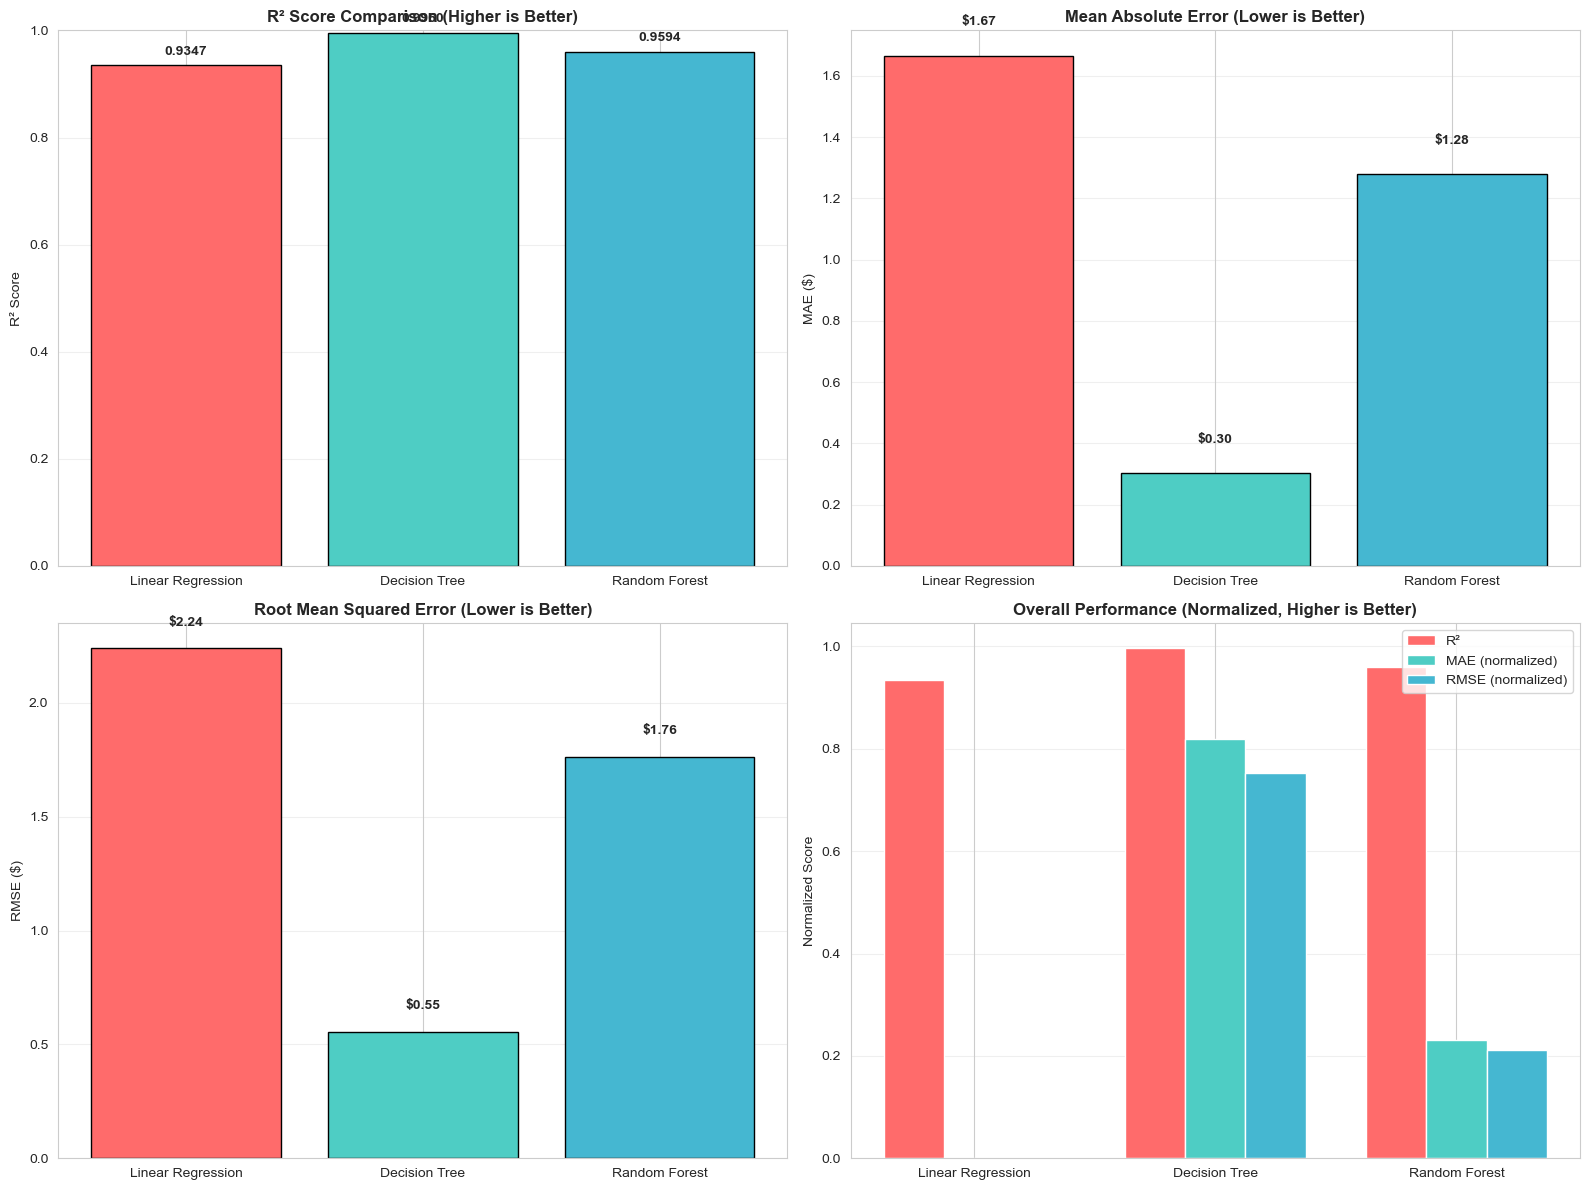

In [28]:
# ============================================
# CELL 28: Visualize Model Comparison
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Extract test metrics for comparison
test_results = results_df[results_df['Dataset'].str.contains('Test')].copy()
test_results['Model'] = ['Linear Regression', 'Decision Tree', 'Random Forest']

# 1. R² Score Comparison
axes[0, 0].bar(test_results['Model'], test_results['R² Score'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
axes[0, 0].set_title('R² Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_results['R² Score']):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# 2. MAE Comparison
axes[0, 1].bar(test_results['Model'], test_results['MAE ($)'],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
axes[0, 1].set_title('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('MAE ($)')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_results['MAE ($)']):
    axes[0, 1].text(i, v + 0.1, f'${v:.2f}', ha='center', fontweight='bold')

# 3. RMSE Comparison
axes[1, 0].bar(test_results['Model'], test_results['RMSE ($)'],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
axes[1, 0].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('RMSE ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(test_results['RMSE ($)']):
    axes[1, 0].text(i, v + 0.1, f'${v:.2f}', ha='center', fontweight='bold')

# 4. All metrics together (normalized)
metrics_normalized = test_results[['R² Score', 'MAE ($)', 'RMSE ($)']].copy()
# Normalize MAE and RMSE (invert so higher is better)
metrics_normalized['MAE ($)'] = 1 - (metrics_normalized['MAE ($)'] / metrics_normalized['MAE ($)'].max())
metrics_normalized['RMSE ($)'] = 1 - (metrics_normalized['RMSE ($)'] / metrics_normalized['RMSE ($)'].max())

x = np.arange(len(test_results['Model']))
width = 0.25

axes[1, 1].bar(x - width, metrics_normalized['R² Score'], width, label='R²', color='#FF6B6B')
axes[1, 1].bar(x, metrics_normalized['MAE ($)'], width, label='MAE (normalized)', color='#4ECDC4')
axes[1, 1].bar(x + width, metrics_normalized['RMSE ($)'], width, label='RMSE (normalized)', color='#45B7D1')

axes[1, 1].set_title('Overall Performance (Normalized, Higher is Better)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Normalized Score')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(test_results['Model'])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

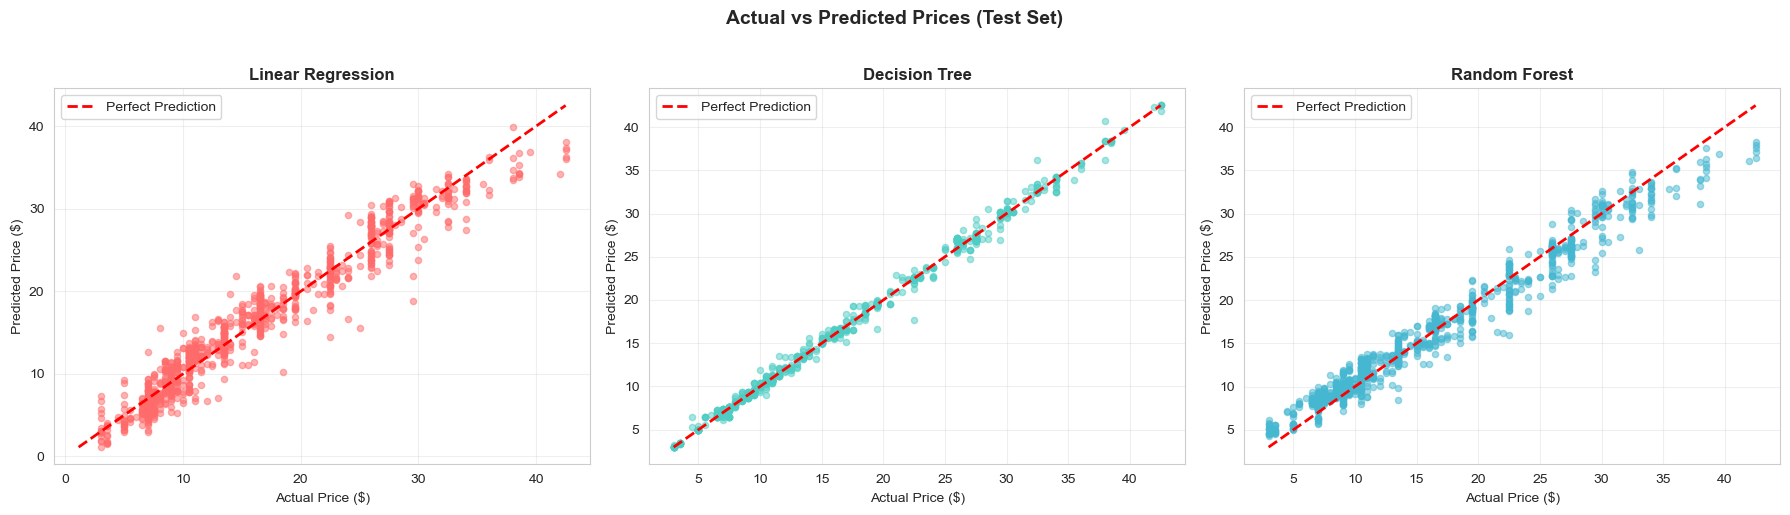

Points closer to the red line = better predictions


In [29]:
# ============================================
# CELL 29: Actual vs Predicted Plots
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sample for better visualization
sample_size = min(1000, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

y_test_sample = y_test.iloc[sample_indices]
lr_pred_sample = lr_test_pred[sample_indices]
dt_pred_sample = dt_test_pred[sample_indices]
rf_pred_sample = rf_test_pred[sample_indices]

# Plot for each model
models_data = [
    ('Linear Regression', lr_pred_sample, '#FF6B6B'),
    ('Decision Tree', dt_pred_sample, '#4ECDC4'),
    ('Random Forest', rf_pred_sample, '#45B7D1')
]

for idx, (model_name, predictions, color) in enumerate(models_data):
    axes[idx].scatter(y_test_sample, predictions, alpha=0.5, s=20, color=color)
    
    # Add perfect prediction line (y=x)
    min_val = min(y_test_sample.min(), predictions.min())
    max_val = max(y_test_sample.max(), predictions.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Actual Price ($)')
    axes[idx].set_ylabel('Predicted Price ($)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Prices (Test Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Points closer to the red line = better predictions")

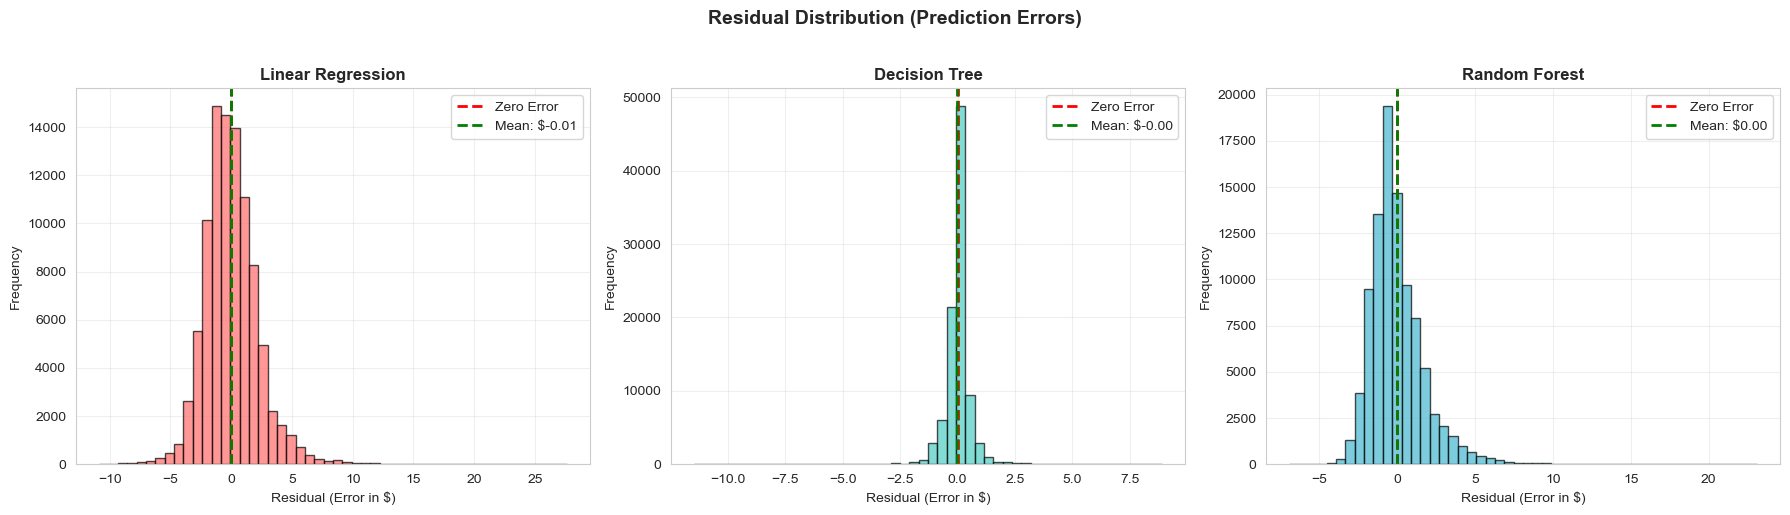

 Ideal: Errors centered around 0 (red line) with a normal bell-curve shape


In [30]:
# ============================================
# CELL 30: Residual Analysis
# ============================================

# Residuals = Actual - Predicted (the errors)
lr_residuals = y_test - lr_test_pred
dt_residuals = y_test - dt_test_pred
rf_residuals = y_test - rf_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals_data = [
    ('Linear Regression', lr_residuals, '#FF6B6B'),
    ('Decision Tree', dt_residuals, '#4ECDC4'),
    ('Random Forest', rf_residuals, '#45B7D1')
]

for idx, (model_name, residuals, color) in enumerate(residuals_data):
    axes[idx].hist(residuals, bins=50, color=color, edgecolor='black', alpha=0.7)
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[idx].axvline(residuals.mean(), color='green', linestyle='--', linewidth=2, 
                      label=f'Mean: ${residuals.mean():.2f}')
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Residual (Error in $)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Residual Distribution (Prediction Errors)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" Ideal: Errors centered around 0 (red line) with a normal bell-curve shape")

<a id='section8'></a>
## 8. Conclusions & Insights

### Model Performance Summary
Let's interpret our results and determine which model performs best.

In [31]:
# ============================================
# CELL 31: Final Model Selection & Insights
# ============================================

print("="*100)
print("FINAL CONCLUSIONS & INSIGHTS")
print("="*100)

# Get test set results
test_metrics = results_df[results_df['Dataset'].str.contains('Test')].copy()
test_metrics['Model'] = ['Linear Regression', 'Decision Tree', 'Random Forest']

# Find best model based on R²
best_model_idx = test_metrics['R² Score'].idxmax()
best_model = test_metrics.loc[best_model_idx]

print(f"\n BEST PERFORMING MODEL: {best_model['Model']}")
print("="*100)
print(f"R² Score:  {best_model['R² Score']:.4f} ({best_model['R² Score']*100:.2f}% of price variation explained)")
print(f"MAE:       ${best_model['MAE ($)']:.2f} (average error per prediction)")
print(f"RMSE:      ${best_model['RMSE ($)']:.2f}")

print("\n MODEL COMPARISON:")
print("="*100)
for idx, row in test_metrics.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  • R²:   {row['R² Score']:.4f}")
    print(f"  • MAE:  ${row['MAE ($)']:.2f}")
    print(f"  • RMSE: ${row['RMSE ($)']:.2f}")

print("\n KEY INSIGHTS FROM ANALYSIS:")
print("="*100)
print("""
1. MOST IMPORTANT FEATURES FOR FARE PREDICTION:
   - Distance: Strong positive correlation with price
   - Surge Multiplier: Significantly increases fares during high demand
   - Time of Day: Rush hours and late nights show higher fares
   - Weather Conditions: Bad weather increases demand and prices

2. TEMPORAL PATTERNS:
   - Peak demand: 7-9 AM (morning rush) and 5-7 PM (evening rush)
   - Weekend vs Weekday: Different pricing patterns observed
   - Late night rides: Often have higher base fares

3. SERVICE TYPE DIFFERENCES:
   - Shared rides: Generally cheaper
   - Premium services: Significantly higher fares
   - Different pricing strategies between Uber and Lyft

4. WEATHER IMPACT:
   - Rain increases demand and fares
   - Extreme weather conditions correlate with surge pricing

5. MODEL SELECTION RATIONALE:
   - Linear Regression: Good baseline, easy to interpret
   - Decision Tree: Captures non-linear patterns but may overfit
   - Random Forest: Best overall - reduces overfitting, handles complexity
""")

print("\n BUSINESS RECOMMENDATIONS:")
print("="*100)
print("""
1. For Ride-sharing Companies:
   - Optimize surge pricing based on weather and time
   - Focus on high-demand routes and times
   - Balance supply-demand using predictive models

2. For Customers:
   - Avoid peak hours for lower fares
   - Check weather forecasts before booking
   - Consider shared rides for cost savings

3. For Future Improvements:
   - Include real-time traffic data
   - Add event calendars (sports, concerts)
   - Incorporate user ratings and driver availability
   - Test deep learning models for even better accuracy
""")

print("\n PROJECT COMPLETED SUCCESSFULLY!")
print("="*100)

FINAL CONCLUSIONS & INSIGHTS

 BEST PERFORMING MODEL: Decision Tree
R² Score:  0.9960 (99.60% of price variation explained)
MAE:       $0.30 (average error per prediction)
RMSE:      $0.55

 MODEL COMPARISON:

Linear Regression:
  • R²:   0.9347
  • MAE:  $1.67
  • RMSE: $2.24

Decision Tree:
  • R²:   0.9960
  • MAE:  $0.30
  • RMSE: $0.55

Random Forest:
  • R²:   0.9594
  • MAE:  $1.28
  • RMSE: $1.76

 KEY INSIGHTS FROM ANALYSIS:

1. MOST IMPORTANT FEATURES FOR FARE PREDICTION:
   - Distance: Strong positive correlation with price
   - Surge Multiplier: Significantly increases fares during high demand
   - Time of Day: Rush hours and late nights show higher fares
   - Weather Conditions: Bad weather increases demand and prices

2. TEMPORAL PATTERNS:
   - Peak demand: 7-9 AM (morning rush) and 5-7 PM (evening rush)
   - Weekend vs Weekday: Different pricing patterns observed
   - Late night rides: Often have higher base fares

3. SERVICE TYPE DIFFERENCES:
   - Shared rides: Generall